# 03 · Analyze, Part A: auditing Google's own model for this question

Google's lab **GSP229, *Predict Visitor Purchases with a Classification Model in BigQuery ML***, predicts `will_buy_on_return_visit` from a visitor's first visit to the Google Merchandise Store and reports **ROC-AUC 0.91**. It is the closest published model to decision D2 (which first-time visitors are worth remarketing to), so I audit it before building my own.

**Hypothesis H4** ([reports/01_ask.md](../reports/01_ask.md)): the lab model's ROC-AUC is lower on external visitors than on all visitors, because part of its skill is recognizing Google employees.

What this notebook does:
1. Checks which table the lab trains on (it isn't the public sample)
2. Uses that table's unredacted referrers to identify employees, and scores my inferred flag against them
3. Recreates the lab's models **in BigQuery ML with the lab's own SQL** and reproduces the published scores
4. Tests H4 with a paired bootstrap, tests the mechanism, and shows who the model would target

Full write-up: [reports/04_analyze.md](../reports/04_analyze.md) (Part A).

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics import roc_auc_score

from src import bq, viz
from src.lab_audit import (LABEL, MODEL_1, MODEL_2, PUBLISHED_ROC_AUC, fit, scores, metrics,
                           paired_bootstrap_auc_gap, paired_bootstrap_auc_diff)
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

# True re-creates the lab's four BigQuery ML models in YOUR project (dataset `lab_audit`, ~7 minutes).
# False reads their evaluation and prediction results, committed in data/raw/.
RUN_BQML = False
N_BOOT = 2000   # bootstrap resamples; each paired bootstrap takes ~90 s

## 1. The lab trains on a different table than the public sample

The lab's SQL reads `data-to-insights.ecommerce.web_analytics`, not `bigquery-public-data.google_analytics_sample`. Matching sessions on `(fullVisitorId, visitId, visitStartTime)`:

In [2]:
bq.query("audit/a03_lab_table_vs_public.sql", cache="a03_lab_table_vs_public")

,membership,sessions,lab_purchase_sessions,public_purchase_sessions,lab_revenue_usd,public_revenue_usd,purchase_in_both
0,in both,832872,10642,10642,1628610.0,1628572.0,10642
1,lab only,137660,13314,0,2993673.0,NaN,0
2,public only,70781,0,910,NaN,151578.0,0


Where the two tables overlap (832,872 sessions), purchases and revenue match almost exactly. But the lab's table has **137,660 sessions the public sample lacks, with 13,314 purchase sessions and USD 3.0M of revenue**, which roughly doubles the store's purchases. So any audit of the lab has to use the lab's own table.

In [3]:
# The 137,660 lab-only sessions by channel, with internal Google referrers counted separately
lab_only = bq.query("audit/a07_lab_only_sessions.sql", cache="a07_lab_only_sessions")
lab_only.assign(conversion_pct=lambda d: (100 * d.purchase_sessions / d.sessions).round(1))

,channel_or_internal,sessions,purchase_sessions,revenue_usd,conversion_pct
0,Organic Search,48898,891,140629.0,1.8
1,Google-internal referrer,36968,7213,1585598.0,19.5
2,Direct,31300,4847,1200533.0,15.5
3,Social,9004,73,15443.0,0.8
4,Referral,4631,66,13278.0,1.4
5,Paid Search,3377,148,24805.0,4.4
6,Affiliates,2364,5,531.0,0.2
7,Display,1113,71,12856.0,6.4
8,(Other),5,0,NaN,0.0


The lab-only sessions include **36,968 from internal Google referrers** (7,213 purchases, USD 1.59M) and **31,300 Direct sessions converting at 15.5%**, which looks like employees returning by bookmark. The public sample appears to be a version of the data with internal referrers redacted and much internal traffic removed.

## 2. The lab's table shows the referrer the public sample hides

In [4]:
bq.query("audit/a04_lab_table_referrals.sql", cache="a04_lab_table_referrals")

,channel,source,referral_path,sessions,purchase_sessions,revenue_usd
0,Referral,mall.googleplex.com,/,79767,7556,1189657.0
1,Referral,analytics.google.com,/analytics/web/,15201,0,NaN
2,Referral,sites.google.com,/a/google.com/googletopia/discounts-deals-and-...,9073,1809,422936.0
3,Referral,gdeals.googleplex.com,/offer/2145,6536,1853,429636.0
4,Referral,moma.corp.google.com,/,4253,572,134767.0
5,Referral,google.com,/permissions/using-the-logo.html,3806,5,380.0
6,Referral,siliconvalley.about.com,/od/Things-To-Do-in-Silicon-Valley/fl/How-To-V...,2138,7,419.0
7,Referral,qiita.com,/YKEI_mrn/items/c10b14f9a69ff71b1b7a,1816,1,272.0


The top referrer is **`mall.googleplex.com`**, Google's internal employee store link. Other internal Google hosts appear too. Listing every Google-internal referrer (`*.googleplex.com`, `*.corp.google.com`, internal tools, the employee perks site, and Google's internal Sites domain):

In [5]:
domains = bq.query("audit/a05_internal_domains.sql", cache="a05_internal_domains")
display(domains.head(6))
domains[["sessions", "purchase_sessions", "revenue_usd"]].sum().rename("all internal referrers")

,source,sites_domain,sessions,purchase_sessions,revenue_usd
0,mall.googleplex.com,NaN,79767,7556,1189657.0
1,sites.google.com,/a/google.com/,11351,1967,459534.0
2,gdeals.googleplex.com,NaN,6536,1853,429636.0
3,moma.corp.google.com,NaN,4253,572,134767.0
4,cases.corp.google.com,NaN,48,0,NaN
5,growcms.googleplex.com,NaN,36,2,473.0


sessions              102097.0
purchase_sessions      11950.0
revenue_usd          2214067.0
Name: all internal referrers, dtype: Float64

In [6]:
# The four large internal hosts above, and the long tail of small internal tools behind them.
# This list covers googleplex.com, corp.google.com and internal Sites only; the employee flag used
# from section 3 on also counts the employee perks site and a few other Google tool domains.
big_four = ["mall.googleplex.com", "sites.google.com", "gdeals.googleplex.com", "moma.corp.google.com"]
small_hosts = domains[~domains.source.isin(big_four)]
print(f"Hosts in this list (googleplex.com, corp.google.com, internal Sites): {len(domains)}")
print(f"Beyond the four large ones: {len(small_hosts)} hosts with {small_hosts.sessions.sum():,} sessions "
      f"and {small_hosts.purchase_sessions.sum():,} purchase sessions")

Hosts in this list (googleplex.com, corp.google.com, internal Sites): 33
Beyond the four large ones: 29 hosts with 190 sessions and 2 purchase sessions


In [7]:
# Public-sample sessions with a redacted referrer (Referral from "(direct)"), matched to the same sessions here
redacted = bq.query("audit/a06_verify_public_internal_flag.sql", cache="a06_verify_public_internal_flag")
redacted[redacted.public_label == "flagged internal (path /)"]

,public_label,true_source,sessions
0,flagged internal (path /),mall.googleplex.com,61252
1,flagged internal (path /),moma.corp.google.com,418
2,flagged internal (path /),googleweblight.com,249


The public sample hides these referrers: their sessions appear as Referral from `(direct)`. Matched session by session, most of those with path `/` (the pattern my Prepare-phase flag uses) came from `mall.googleplex.com`. But **249 came from `googleweblight.com`**, a public Google mobile proxy that the public sample also redacts. That is one source of false positives for my flag, which the next section measures.

## 3. Checking my employee flag against the unredacted referrers

In Prepare I *inferred* employee traffic in the public sample (Referral + source `(direct)` + path `/`, 66% from Google office cities). The lab's table gives ground truth: a visitor is internal if any of their sessions there came from an internal referrer.

In [8]:
acc = bq.query("audit/a08_internal_flag_accuracy.sql", cache="a08_internal_flag_accuracy")
display(acc)

def cell(flag, truth, col):
    return acc.loc[(acc.our_flag == flag) & (acc.ground_truth == truth), col].sum()

rows = {}
for col, unit in [("visitors", "visitors"), ("purchase_sessions", "purchase sessions")]:
    tp = cell("flagged internal", "truly internal", col)
    fp = cell("flagged internal", "truly external", col)
    fn = cell("treated as external", "truly internal", col)
    rows[unit] = {"precision": tp / (tp + fp), "recall": tp / (tp + fn)}
display(pd.DataFrame(rows).T.style.format("{:.1%}"))

external_purchases = acc.loc[acc.our_flag == "treated as external", "purchase_sessions"].sum()
missed = cell("treated as external", "truly internal", "purchase_sessions")
print(f"Employee purchases our flag misses: {missed} = {missed / external_purchases:.1%} of what we treat as external")

,our_flag,ground_truth,visitors,sessions,purchase_sessions,revenue_usd
0,flagged internal,truly external,291,509,11,687.0
1,flagged internal,truly internal,34225,71603,5058,684740.0
2,flagged internal,visitor not in lab table,2816,4424,339,44950.0
3,treated as external,truly external,620179,759025,5632,957690.0
4,treated as external,truly internal,2711,4780,94,11195.0
5,treated as external,visitor not in lab table,53945,63312,418,80888.0


,precision,recall
visitors,99.2%,92.7%
purchase sessions,99.8%,98.2%


Employee purchases our flag misses: 94 = 1.5% of what we treat as external


My inferred flag holds up: **99% precision, and it catches 98% of employee purchases.** What it misses is about 1.5% of the purchases I treat as external, too small to change any conclusion in D1 or D2.

## 4. Who the lab learns from

The lab's training and evaluation data, rebuilt with the lab's exact SQL (same filters, splits, and `GROUP BY`), plus the ground-truth employee flag (not a feature):

In [9]:
lab = bq.query("audit/a09_lab_model_data.sql", cache="a09_lab_model_data")
(lab.assign(internal_positive=lab.is_internal & (lab[LABEL] == 1))
    .groupby("split")
    .agg(first_visits=(LABEL, "size"), positives=(LABEL, "sum"), internal_positives=("internal_positive", "sum"))
    .assign(positive_rate_pct=lambda d: (100 * d.positives / d.first_visits).round(2),
            pct_positives_internal=lambda d: (100 * d.internal_positives / d.positives).round(1))
    .loc[["train", "eval"]])

,first_visits,positives,internal_positives,positive_rate_pct,pct_positives_internal
split,,,,,
train,573001,8771,5313,1.53,60.6
eval,102025,1650,1218,1.62,73.8


In [10]:
# Employees' share of the lab's first visits, by split
first_visit_employees = (lab.groupby("split").is_internal
                            .agg(employees="sum", first_visits="size")
                            .loc[["train", "eval"]]
                            .assign(share=lambda d: d.employees / d.first_visits))
for r in first_visit_employees.itertuples():
    print(f"{r.Index}: {r.employees:,} of {r.first_visits:,} first visits are employees = {r.share:.1%} ({r.share:.2%})")
print(f"Range to the nearest percent: {first_visit_employees.share.min():.0%} to {first_visit_employees.share.max():.0%}")

train: 33,919 of 573,001 first visits are employees = 5.9% (5.92%)
eval: 9,542 of 102,025 first visits are employees = 9.4% (9.35%)
Range to the nearest percent: 6% to 9%


**61% of the lab's training positives and 74% of its evaluation positives are Google employees**, even though employees are only 6–9% of first visits. The label "will buy on a return visit" mostly describes staff coming back to their company store.

## 5. Recreating the lab's models in BigQuery ML

[`sql/audit/a10_bqml_create_models.sql`](../sql/audit/a10_bqml_create_models.sql) is the lab's SQL unchanged, apart from the dataset name. [`a12`](../sql/audit/a12_bqml_audit_models.sql) adds two audit variants of model 2: one **without source, medium and channel**, and one **trained on external visitors only**. Everything else is identical.

In [11]:
if RUN_BQML:
    for f in ["audit/a10_bqml_create_models.sql", "audit/a12_bqml_audit_models.sql"]:
        bq.execute(f)
elif not all((bq.CACHE_DIR / f"{name}.parquet").exists() for name in ["a11_bqml_evaluate", "a13_bqml_predictions"]):
    raise FileNotFoundError("data/raw/a11_bqml_evaluate.parquet or a13_bqml_predictions.parquet is missing: restore the committed "
                            "files (git restore data/raw) or set RUN_BQML = True to recreate the BigQuery ML models (about 7 minutes)")

evaluation = bq.query("audit/a11_bqml_evaluate.sql", cache="a11_bqml_evaluate", refresh=RUN_BQML)
evaluation.assign(published_roc_auc=evaluation.model.map(PUBLISHED_ROC_AUC)).round(3)

,model,eval_rows,roc_auc,log_loss,published_roc_auc
0,model_1,all (as published),0.724,0.077,0.72
1,model_1,external only,0.756,0.035,0.72
2,model_2,all (as published),0.909,0.066,0.91
3,model_2,external only,0.862,0.030,0.91


**Both published scores reproduce exactly** (0.724 vs 0.72, and 0.909 vs 0.91), so the rest of this notebook audits the lab's actual model rather than an approximation. The external-only rows already show model 2 dropping to 0.862. ML.EVALUATE's AUC differs slightly from an exact AUC on the row-level predictions, so section 6 shows 0.910 and 0.863 for the same model.

Model 1 moves the other way: it rises to 0.756 on outside visitors. With no traffic-source features it can't single out employees, so the inflation is specific to model 2, the published 0.91 (the mechanism test in section 6 shows why).

## 6. H4: is the lab's ROC-AUC inflated by employees?

Row-level scores from the three BigQuery ML models on the lab's evaluation set ([`a13`](../sql/audit/a13_bqml_predictions.sql)). ROC-AUC is compared on all first visits (how the lab evaluates) and on external visitors only. PR-AUC and top-1% precision are added because positives are rare (1.6% overall, 0.5% external).

In [12]:
pred = bq.query("audit/a13_bqml_predictions.sql", cache="a13_bqml_predictions", refresh=RUN_BQML)
assert len(pred) == len(lab[lab.split == "eval"]), "one prediction per lab evaluation row"

y = pred[LABEL].to_numpy()
ext = ~pred.is_internal.to_numpy()
MODELS = {
    "Lab model, as published": "score_model_2",
    "Without source, medium, channel": "score_no_source",
    "Trained on external visitors only": "score_external_trained",
}
results = pd.DataFrame({
    (name, rows): metrics(y[mask], pred.loc[mask, col].to_numpy())
    for name, col in MODELS.items()
    for rows, mask in [("all first visits", np.ones_like(ext)), ("external only", ext)]
}).T
results.style.format({
    "rows": "{:,.0f}", "positives": "{:,.0f}", "base_rate": "{:.2%}", "roc_auc": "{:.3f}", "pr_auc": "{:.3f}",
    "precision_top_1pct": "{:.1%}", "lift_top_1pct": "{:.1f}x", "lift_top_10pct": "{:.1f}x",
})

In [13]:
# Why a13 joins the three prediction tables on row_key: the lab's unique_session_id repeats when a
# visit is split at midnight, and joining on it multiplies those rows
eval_ids = lab.loc[lab.split == "eval", ["unique_session_id"]]
pred_ids = pred[["unique_session_id"]]   # each ML.PREDICT output has one row per evaluation row
naive = (eval_ids.merge(pred_ids, on="unique_session_id")
                 .merge(pred_ids, on="unique_session_id")
                 .merge(pred_ids, on="unique_session_id"))
repeated = eval_ids.unique_session_id.duplicated(keep=False)
print(f"unique_session_id values that repeat: {eval_ids.unique_session_id[repeated].nunique():,} ({repeated.sum():,} rows)")
print(f"Joined on unique_session_id: {len(naive):,} rows from {len(eval_ids):,} evaluation rows, "
      f"so {len(naive) - len(eval_ids):,} duplicated rows")
print(f"Joined on row_key, as a13 does: {len(pred):,} rows (row_key unique: {pred.row_key.is_unique})")

unique_session_id values that repeat: 119 (238 rows)
Joined on unique_session_id: 103,691 rows from 102,025 evaluation rows, so 1,666 duplicated rows
Joined on row_key, as a13 does: 102,025 rows (row_key unique: True)


**The formal test:** a paired bootstrap resamples evaluation rows and recomputes both AUCs on each resample, so the gap's confidence interval accounts for the two AUCs sharing most of their rows.

In [14]:
h4 = {name: paired_bootstrap_auc_gap(y, pred[col].to_numpy(), ext, n_boot=N_BOOT)
      for name, col in list(MODELS.items())[:2]}
pd.DataFrame(h4).T.rename(columns={"auc_gap": "AUC(all) - AUC(external)"}).round(4)

,AUC(all) - AUC(external),ci_low,ci_high,p_gap_le_0
"Lab model, as published",0.0468,0.0353,0.0593,0.000
"Without source, medium, channel",0.0027,-0.0078,0.0131,0.299


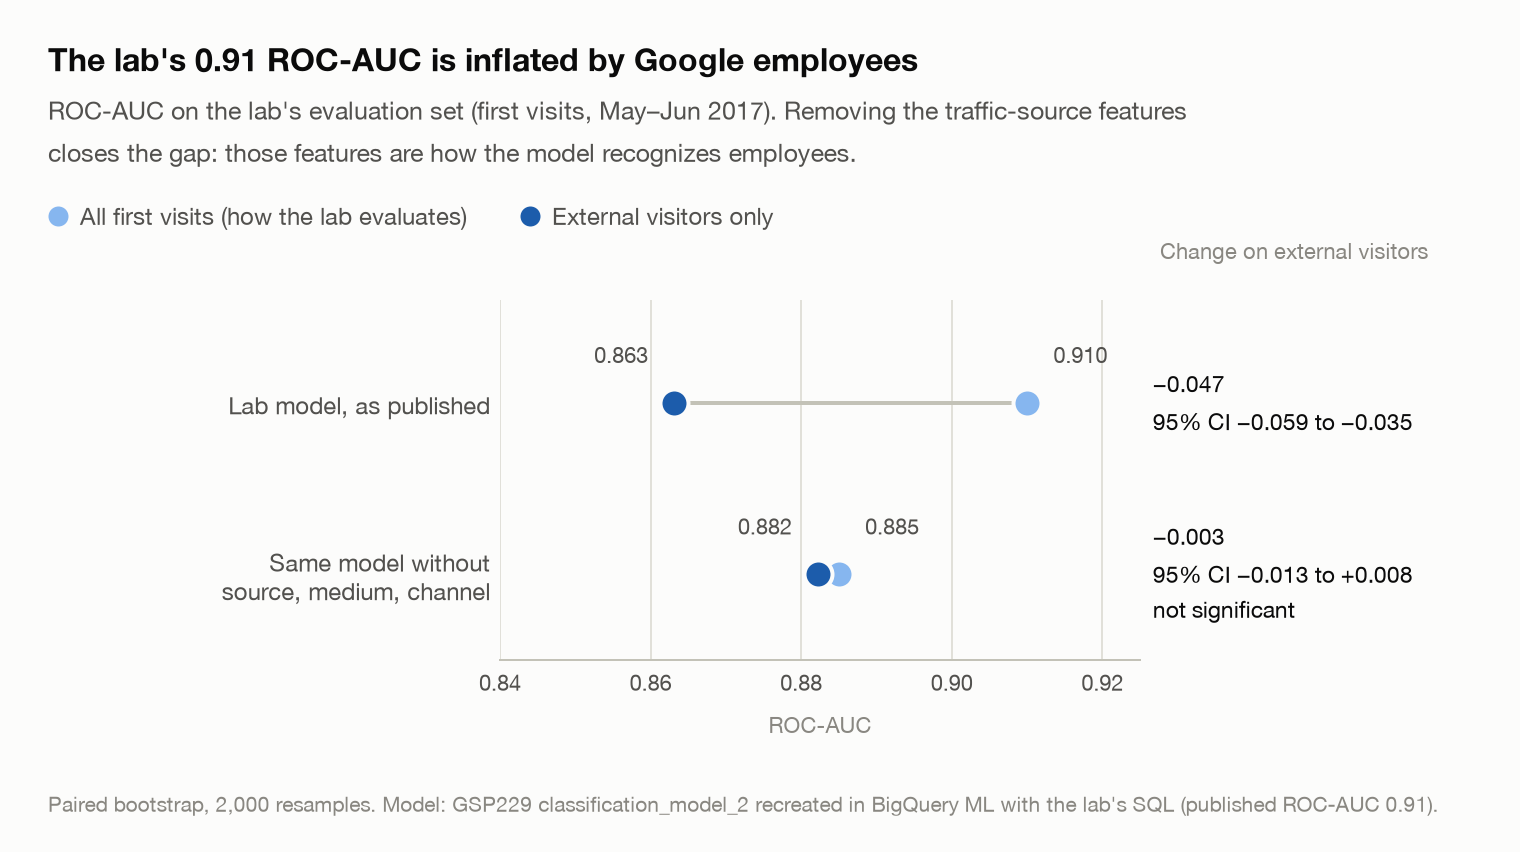

In [15]:
chart_rows = []
for (name, col), label in zip(list(MODELS.items())[:2],
                              ["Lab model, as published", "Same model without\nsource, medium, channel"]):
    r, s = h4[name], pred[col].to_numpy()
    significance = "" if r["ci_low"] > 0 else "\nnot significant"
    chart_rows.append({
        "label": label,
        "auc_all": roc_auc_score(y, s),
        "auc_external": roc_auc_score(y[ext], s[ext]),
        "gap_text": f"{viz.signed(-r['auc_gap'])}\n95% CI {viz.signed(-r['ci_high'])} to {viz.signed(-r['ci_low'])}{significance}",
    })
fig = viz.auc_dumbbell_chart(
    chart_rows,
    title="The lab's 0.91 ROC-AUC is inflated by Google employees",
    subtitle=("ROC-AUC on the lab's evaluation set (first visits, May–Jun 2017). Removing the traffic-source features\n"
              "closes the gap: those features are how the model recognizes employees."),
    note=(f"Paired bootstrap, {N_BOOT:,} resamples. Model: GSP229 classification_model_2 recreated in BigQuery ML "
          "with the lab's SQL (published ROC-AUC 0.91)."),
)
viz.show_saved(fig, ROOT / "reports/figures/lab_audit_auc_gap.png")

**H4 is supported.** On external visitors the lab model's ROC-AUC is **0.047 lower** (95% CI 0.035 to 0.059), and no bootstrap resample shows no gap.

**The mechanism test confirms why.** Without source, medium, and channel, the gap disappears (0.003, CI −0.008 to +0.013). Those three features are how the model spots employees: `mall.googleplex.com` and the other internal referrers are values of `source`.

## 7. Who the lab model would target

If the store used the lab model to choose a remarketing audience, who would be in it?

In [16]:
ranked = pred.sort_values("score_model_2", ascending=False)
tiers = []
for frac, name in [(0.01, "Top 1%"), (0.05, "Top 5%"), (0.10, "Top 10%"), (1.0, "All first visits")]:
    top = ranked.head(int(round(len(ranked) * frac)))
    tiers.append({"group": name, "visitors": len(top), "employee_share": top.is_internal.mean(),
                  "buyers": int(top[LABEL].sum()),
                  "external_buyers": int(top.loc[~top.is_internal, LABEL].sum())})
tiers = pd.DataFrame(tiers)
display(tiers.style.format({"visitors": "{:,}", "employee_share": "{:.1%}"}))

detector = pd.Series({name: roc_auc_score(pred.is_internal, pred[col]) for name, col in MODELS.items()},
                     name="ROC-AUC for predicting 'is a Google employee'")
detector.round(3)

,group,visitors,employee_share,buyers,external_buyers
0,Top 1%,"1,020",98.8%,158,2
1,Top 5%,"5,101",87.9%,818,43
2,Top 10%,"10,202",76.8%,1153,112
3,All first visits,"102,025",9.4%,1650,432


Lab model, as published              0.974
Without source, medium, channel      0.880
Trained on external visitors only    0.867
Name: ROC-AUC for predicting 'is a Google employee', dtype: float64

In [17]:
# Employee share of each model's top 1%, ranked the same way as the table above
n_top = int(round(len(pred) * 0.01))
top1_employees = pd.DataFrame([
    {"model": name, "employees": int(pred.sort_values(col, ascending=False).head(n_top).is_internal.sum())}
    for name, col in MODELS.items()
]).assign(share=lambda d: d.employees / n_top)
for r in top1_employees.itertuples():
    print(f"{r.model}: {r.employees:,} of its top 1% ({n_top:,} visitors) are employees = {r.share:.0%} ({r.share:.2%})")

Lab model, as published: 1,008 of its top 1% (1,020 visitors) are employees = 99% (98.82%)
Without source, medium, channel: 673 of its top 1% (1,020 visitors) are employees = 66% (65.98%)
Trained on external visitors only: 606 of its top 1% (1,020 visitors) are employees = 59% (59.41%)


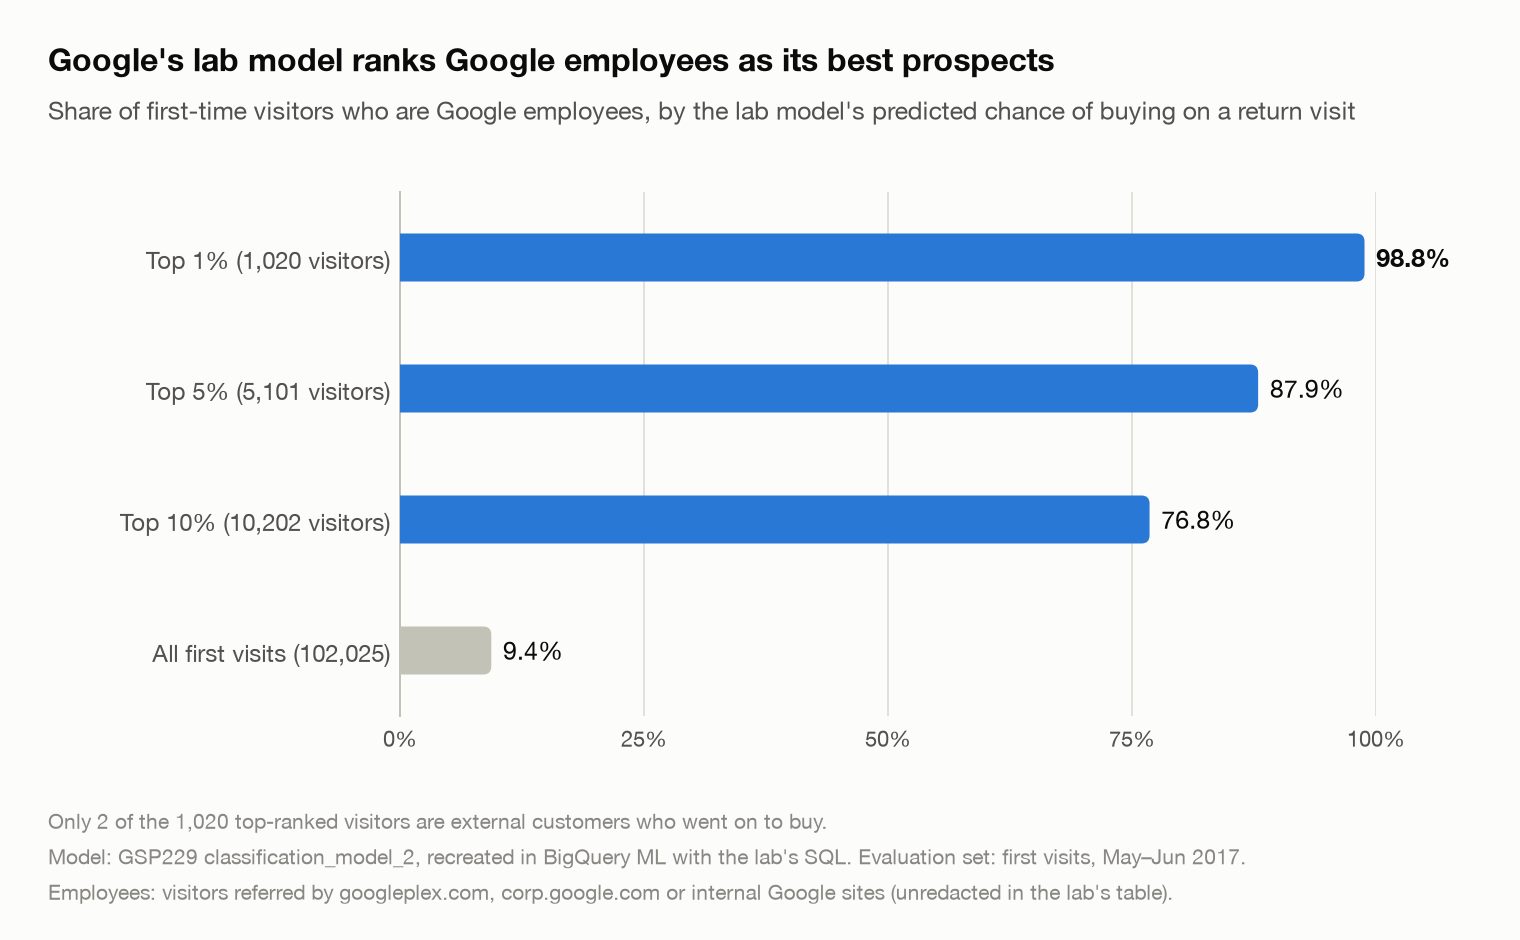

In [18]:
top1 = tiers.iloc[0]
fig = viz.lab_top_ranked_chart(
    [f"{g} ({v:,} visitors)" if g != "All first visits" else f"{g} ({v:,})" for g, v in zip(tiers.group, tiers.visitors)],
    tiers.employee_share.tolist(), reference_index=3,
    title="Google's lab model ranks Google employees as its best prospects",
    subtitle="Share of first-time visitors who are Google employees, by the lab model's predicted chance of buying on a return visit",
    note=(f"Only {top1.external_buyers} of the {top1.visitors:,} top-ranked visitors are external customers who went on to buy.\n"
          "Model: GSP229 classification_model_2, recreated in BigQuery ML with the lab's SQL. Evaluation set: first visits, May–Jun 2017.\n"
          "Employees: visitors referred by googleplex.com, corp.google.com or internal Google sites (unredacted in the lab's table)."),
)
viz.show_saved(fig, ROOT / "reports/figures/lab_audit_top_ranked.png")

The lab model's **top 1% of prospects are 98.8% Google employees**, and only 2 of those 1,020 visitors are external customers who went on to buy. (Its score also separates employees from other visitors almost perfectly, but that's expected rather than a finding: the employee label is built from the same traffic-source field the model uses.) A remarketing audience built from this model would mostly pay to advertise to Google's own staff.

The two audit variants still rank employees highly (59–66% of their top 1%), because employees also browse deeply and add to cart. **So removing features isn't enough: employees have to be removed from the population**, which my D2 table already does.

## 8. How well do the models rank real customers?

What matters for D2 is performance on external visitors only. A paired bootstrap on the same external rows compares each variant with the lab model:

In [19]:
e = pred[~pred.is_internal]
comparison = pd.DataFrame({
    name: paired_bootstrap_auc_diff(e[LABEL].to_numpy(), e[col].to_numpy(), e.score_model_2.to_numpy(), n_boot=N_BOOT)
    for name, col in list(MODELS.items())[1:]
}).T.rename(columns={"auc_diff": "AUC(variant) - AUC(lab model)"})
comparison.round(4)

,AUC(variant) - AUC(lab model),ci_low,ci_high,p_diff_le_0
"Without source, medium, channel",0.0191,0.0067,0.0311,0.0015
Trained on external visitors only,0.0141,0.0110,0.0172,0.0000


Both variants score higher on ROC-AUC than the lab model: +0.019 without the traffic-source features (95% CI +0.007 to +0.031) and +0.014 when trained without employees (95% CI +0.011 to +0.017). These gains are statistically real but small. PR-AUC and top-10% lift are only slightly higher, and precision in the top 1% is about the same. So employees mainly inflate the *published* score. The bigger practical damage is who ends up at the top of the list (section 7), which only removing employees from the population fixes.

**Carried into D2:**
- Exclude employees from the *population* (done in Process) and evaluate on external visitors only.
- Treat traffic-source features with care: fit on employee-heavy data, they encode "is an employee".
- Report PR-AUC and top-decile lift. On external visitors the lab design reaches PR-AUC 0.036 and 6.8% precision in its top 1%. ROC-AUC 0.86 sounds strong, but more than 9 of every 10 visitors in the top 1% still don't buy.

## Appendix: portable replica without BigQuery ML

BigQuery ML needs a Google Cloud project that can create models. For readers without one (for example on Kaggle), the same models refit with scikit-learn on the same rows ([`src/lab_audit.py`](../src/lab_audit.py): one-hot encoding plus standardization, no regularization, which is what BigQuery ML does automatically) show the same pattern:

In [20]:
train, evaluation_rows = lab[lab.split == "train"], lab[lab.split == "eval"]
y_eval, ext_eval = evaluation_rows[LABEL].to_numpy(), ~evaluation_rows.is_internal.to_numpy()
replica = {}
for name, spec in [("model_1", MODEL_1), ("model_2", MODEL_2)]:
    s = scores(fit(train, spec), evaluation_rows, spec)
    replica[name] = {"published": PUBLISHED_ROC_AUC[name], "roc_auc_all": roc_auc_score(y_eval, s),
                     "roc_auc_external": roc_auc_score(y_eval[ext_eval], s[ext_eval])}
pd.DataFrame(replica).T.round(3)

,published,roc_auc_all,roc_auc_external
model_1,0.72,0.751,0.785
model_2,0.91,0.919,0.886


The replica's model 2 lands at 0.919 on all visitors and 0.886 on external visitors: the same direction as BigQuery ML, with a smaller gap. Model 1 lands at 0.751 against the published 0.72, because scikit-learn fits to convergence while BigQuery ML's default optimizer stops early; like BigQuery ML's model 1, it rises on external visitors (0.785). That's why the audit's headline numbers use BigQuery ML.